# Análisis de viabilidad del dataset MIRA

Este notebook audita `incendios_forestales_mira_0.csv` sin modificarlo. El objetivo es evaluar si su cobertura, calidad y granularidad permiten estudiar la ocurrencia de **incendios registrados en MIRA** como posible variable objetivo a nivel departamento–semana. La denominación no implica que todos los registros hayan sido confirmados por Bomberos.

In [1]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RUTA_MIRA = Path("incendios_forestales_mira_0.csv")
RUTA_LIMITES = Path("geoBoundaries-URY-ADM1-all/geoBoundaries-URY-ADM1.geojson")
RUTA_METEO = Path("data/processed/open_meteo_department_weekly/open_meteo_department_weekly_2017_2025.parquet")
assert RUTA_MIRA.exists(), f"No se encontró {RUTA_MIRA}"
assert RUTA_LIMITES.exists(), f"No se encontró {RUTA_LIMITES}"
datos_originales = pd.read_csv(RUTA_MIRA, encoding="utf-8-sig")
datos = datos_originales.copy()

## 1. Inventario del archivo

In [2]:
print("Ruta:", RUTA_MIRA.resolve())
print("Tamaño:", RUTA_MIRA.stat().st_size, "bytes")
print("Dimensiones:", datos.shape)
display(pd.DataFrame({"columna": datos.columns, "tipo_inferido": datos.dtypes.astype(str).values}))
display(datos.head())

Ruta: /home/pepo/Materias/PAA/incendios_forestales_mira_0.csv
Tamaño: 23102 bytes
Dimensiones: (113, 14)


,columna,tipo_inferido
0,ObjectID,int64
1,GlobalID,str
2,Número de informe MIRA,int64
3,Tipo de incendio,str
4,Fecha de registro del evento,str
5,Departamento,str
6,Fuente,str
7,Área,float64
8,CreationDate,str
9,Creator,str


,ObjectID,GlobalID,Número de informe MIRA,Tipo de incendio,Fecha de registro del evento,Departamento,Fuente,Área,CreationDate,Creator,EditDate,Editor,x,y
0,1,01213160-4b43-45f3-8303-9c13595ba459,1024,Interface_Urbana,4/25/2022 3:00:00 PM,Montevideo,cecoed,NaN,5/24/2022 6:32:27 PM,sinae_covid_19,5/24/2022 8:31:47 PM,sinae_covid_19,-56.166540,-34.791271
1,2,56fab073-21cd-4993-8b4b-509805e6743e,1006,De_Campo,4/13/2022 3:00:00 PM,Colonia,sgsp,NaN,5/24/2022 6:42:52 PM,sinae_covid_19,6/15/2022 5:21:25 PM,sinae_covid_19,-57.753839,-34.436062
2,3,22cf3c48-9e98-4b0f-874e-091ec277204f,874,Interface_Urbana,1/20/2022 3:00:00 PM,Salto,cecoed,NaN,5/24/2022 6:58:14 PM,sinae_covid_19,5/24/2022 8:30:49 PM,sinae_covid_19,-57.967650,-31.396078
3,4,9e5559ab-4bc4-4580-bbfa-de536e017cdc,861,Interface_Urbana,1/15/2022 3:00:00 PM,Lavalleja,cecoed,NaN,5/24/2022 7:05:43 PM,sinae_covid_19,5/24/2022 8:29:58 PM,sinae_covid_19,-55.232937,-34.363874
4,5,bd3077f1-85df-417c-b3a4-5690457a42ba,973,Interface_Urbana,1/14/2022 3:00:00 PM,Montevideo,sgsp,NaN,5/24/2022 7:15:10 PM,sinae_covid_19,5/24/2022 8:29:13 PM,sinae_covid_19,-56.156305,-34.812312


## 2. Calidad generalLos controles siguientes son diagnósticos. No eliminan ni corrigen registros.

In [3]:
faltantes = pd.DataFrame({
    "faltantes": datos.isna().sum(),
    "porcentaje": datos.isna().mean().mul(100).round(2),
    "unicos_incluye_nulos": datos.nunique(dropna=False),
}).sort_values(["faltantes", "unicos_incluye_nulos"], ascending=False)
display(faltantes)
print("Duplicados exactos:", int(datos.duplicated().sum()))
for columna in ["ObjectID", "GlobalID", "Número de informe MIRA"]:
    print(columna, "- filas con identificador repetido:", int(datos.duplicated(columna, keep=False).sum()))
display(datos.select_dtypes(include="number").describe().T)

,faltantes,porcentaje,unicos_incluye_nulos
Área,82,72.57,18
ObjectID,0,0.00,113
GlobalID,0,0.00,113
Número de informe MIRA,0,0.00,113
CreationDate,0,0.00,113
EditDate,0,0.00,113
x,0,0.00,113
y,0,0.00,113
Fecha de registro del evento,0,0.00,54
Departamento,0,0.00,19


Duplicados exactos: 0
ObjectID - filas con identificador repetido: 0
GlobalID - filas con identificador repetido: 0
Número de informe MIRA - filas con identificador repetido: 0


,count,mean,std,min,25%,50%,75%,max
ObjectID,113.0,57.000000,32.764310,1.000000,29.000000,57.000000,85.000000,113.000000
Número de informe MIRA,113.0,858.902655,156.154740,497.000000,819.000000,925.000000,956.000000,1060.000000
Área,31.0,28.887106,54.438907,0.000300,2.500000,10.000000,40.000000,300.000000
x,113.0,-56.147196,1.238882,-58.320667,-57.095667,-56.166540,-55.302794,-53.545121
y,113.0,-33.583823,1.171913,-34.911838,-34.752425,-33.784493,-32.850050,-30.442876


In [4]:
columnas_texto = datos.select_dtypes(include=["object", "string"]).columns
especiales = {}
for columna in columnas_texto:
    serie = datos[columna].astype("string")
    especiales[columna] = {
        "vacíos_o_espacios": int(serie.str.strip().eq("").sum()),
        "espacios_externos": int(serie.ne(serie.str.strip()).fillna(False).sum()),
        "valores_especiales": int(serie.str.strip().str.lower().isin(["na", "n/a", "null", "none", "sin dato", "s/d", "-"]).sum()),
    }
display(pd.DataFrame(especiales).T)

,vacíos_o_espacios,espacios_externos,valores_especiales
GlobalID,0,0,0
Tipo de incendio,0,0,0
Fecha de registro del evento,0,0,0
Departamento,0,0,0
Fuente,0,0,0
CreationDate,0,0,0
Creator,0,0,0
EditDate,0,0,0
Editor,0,0,0


## 3. Cobertura temporal`Fecha de registro del evento` es el campo que describe la fecha del evento. Se conserva intacto y se crea `fecha_evento` mediante un formato explícito mes/día/año de 12 horas.

In [5]:
FORMATO_FECHA = "%m/%d/%Y %I:%M:%S %p"
datos["fecha_evento"] = pd.to_datetime(datos["Fecha de registro del evento"], format=FORMATO_FECHA, errors="coerce")
for columna in ["Fecha de registro del evento", "CreationDate", "EditDate"]:
    convertida = pd.to_datetime(datos[columna], format=FORMATO_FECHA, errors="coerce")
    print(columna, "| inválidas:", int(convertida.isna().sum()), "| mínimo:", convertida.min(), "| máximo:", convertida.max())
assert datos["fecha_evento"].notna().all()
datos["fecha_inicio_semana"] = datos["fecha_evento"].dt.normalize() - pd.to_timedelta(datos["fecha_evento"].dt.weekday, unit="D")
resumen_temporal = pd.DataFrame({
    "fecha_mínima": [datos["fecha_evento"].min()],
    "fecha_máxima": [datos["fecha_evento"].max()],
    "años_con_registros": [datos["fecha_evento"].dt.year.nunique()],
    "semanas_con_registros": [datos["fecha_inicio_semana"].nunique()],
})
display(resumen_temporal)

Fecha de registro del evento | inválidas: 0 | mínimo: 2018-04-08 15:00:00 | máximo: 2022-06-26 15:00:00
CreationDate | inválidas: 0 | mínimo: 2022-05-24 18:32:27 | máximo: 2022-06-28 19:42:07
EditDate | inválidas: 0 | mínimo: 2022-05-24 20:21:55 | máximo: 2022-07-01 15:13:00


,fecha_mínima,fecha_máxima,años_con_registros,semanas_con_registros
0,2018-04-08 15:00:00,2022-06-26 15:00:00,5,24


In [6]:
por_anio = datos.groupby(datos["fecha_evento"].dt.year).size().rename("registros")
por_mes = datos.groupby(datos["fecha_evento"].dt.to_period("M")).size().rename("registros")
por_semana = datos.groupby("fecha_inicio_semana").size().rename("registros")
display(por_anio.to_frame())
display(por_mes.to_frame())
display(por_semana.sort_values(ascending=False).head(15).to_frame())
semanas_intervalo = pd.date_range(datos["fecha_inicio_semana"].min(), datos["fecha_inicio_semana"].max(), freq="W-MON")
semanas_sin_registros_nacionales = semanas_intervalo.difference(datos["fecha_inicio_semana"].unique())
print("Semanas en el intervalo mínimo–máximo:", len(semanas_intervalo))
print("Semanas con algún registro nacional:", datos["fecha_inicio_semana"].nunique())
print("Semanas intermedias sin registros nacionales:", len(semanas_sin_registros_nacionales))

,registros
fecha_evento,
2018,1
2019,1
2020,14
2021,46
2022,51


,registros
fecha_evento,
2018-04,1
2019-12,1
2020-01,5
2020-02,7
2020-03,1
2020-05,1
2021-01,1
2021-11,3
2021-12,42


,registros
fecha_inicio_semana,
2021-12-27,25
2022-01-10,22
2022-01-03,14
2021-12-20,11
2020-02-03,6
2021-12-13,6
2020-01-20,4
2021-12-06,3
2022-06-13,2


Semanas en el intervalo mínimo–máximo: 221
Semanas con algún registro nacional: 24
Semanas intermedias sin registros nacionales: 197


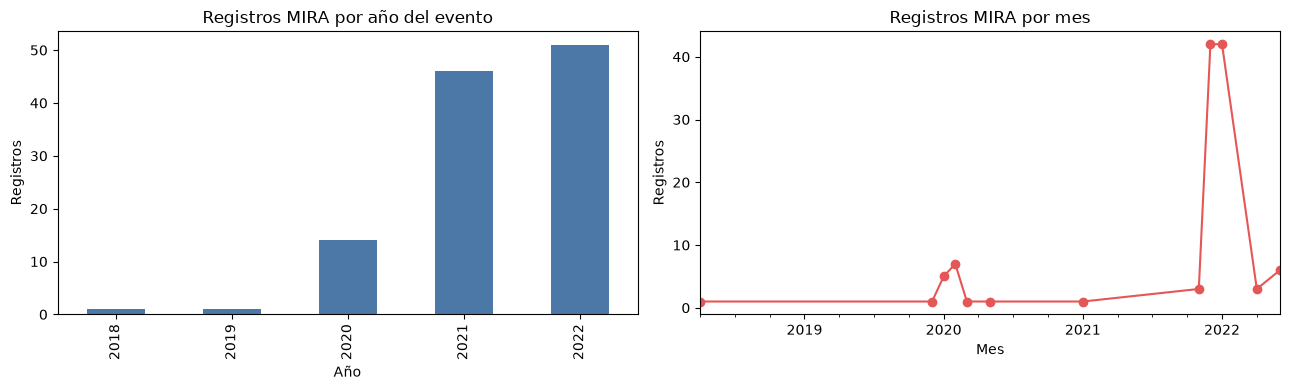

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
por_anio.plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set(title="Registros MIRA por año del evento", xlabel="Año", ylabel="Registros")
por_mes.plot(ax=axes[1], marker="o", color="#e45756")
axes[1].set(title="Registros MIRA por mes", xlabel="Mes", ylabel="Registros")
plt.tight_layout()
plt.show()

**Advertencia de cobertura.** Tener fechas mínima y máxima no demuestra que MIRA haya operado con cobertura homogénea durante todo el intervalo. Las semanas intermedias sin registros no pueden interpretarse automáticamente como semanas sin incendios, porque este CSV no contiene un indicador de cobertura o completitud. El repositorio no aporta una declaración externa del período de cobertura de este extracto; por tanto, no es posible contrastar cobertura declarada y real únicamente con los archivos disponibles. Además, `CreationDate` concentra la creación de los 113 registros entre mayo y junio de 2022, lo que es compatible con una carga retrospectiva, aunque el CSV no permite demostrar su mecanismo.

## 4. Clasificación, fuente y mecanismo de registro

In [8]:
for columna in ["Tipo de incendio", "Fuente", "Departamento", "Creator", "Editor"]:
    tabla = datos[columna].value_counts(dropna=False).rename("frecuencia").to_frame()
    tabla["porcentaje"] = (tabla["frecuencia"] / len(datos) * 100).round(2)
    print("\n", columna)
    display(tabla)
tipos_anio = pd.crosstab(datos["fecha_evento"].dt.year, datos["Tipo de incendio"])
display(tipos_anio)


 Tipo de incendio


,frecuencia,porcentaje
Tipo de incendio,,
De_Campo,55,48.67
Interface_Urbana,33,29.20
Forestal_Plantado,24,21.24
Forestal_Nativo,1,0.88



 Fuente


,frecuencia,porcentaje
Fuente,,
sgsp,62,54.87
cecoed,38,33.63
prensa,13,11.50



 Departamento


...


 Creator


,frecuencia,porcentaje
Creator,,
sinae_covid_19,113,100.0



 Editor


,frecuencia,porcentaje
Editor,,
sinae_covid_19,113,100.0


Tipo de incendio,De_Campo,Forestal_Nativo,Forestal_Plantado,Interface_Urbana
fecha_evento,,,,
2018,1,0,0,0
2019,0,0,1,0
2020,5,1,5,3
2021,22,0,12,12
2022,27,0,6,18


El CSV distingue exactamente las fuentes `sgsp`, `cecoed` y `prensa`. No incluye una columna de estado, validación o confirmación, ni documentación interna que permita equiparar todos los registros con incendios confirmados por Bomberos. `Creator` y `Editor` describen la cuenta que gestionó los registros, no demuestran el organismo que confirmó cada evento.

## 5. Calidad espacialEl CSV ya contiene departamento, longitud `x` y latitud `y`. Se compara el departamento declarado con una asignación independiente mediante `within` sobre la misma capa geoBoundaries ADM1 usada por el proyecto. No se reemplaza el valor original.

In [9]:
limites = gpd.read_file(RUTA_LIMITES).to_crs("EPSG:4326")
puntos = gpd.GeoDataFrame(datos.copy(), geometry=gpd.points_from_xy(datos["x"], datos["y"]), crs="EPSG:4326")
asignados = gpd.sjoin(puntos, limites[["shapeName", "geometry"]], how="left", predicate="within")
def normalizar_nombre(valor):
    texto = unicodedata.normalize("NFKD", str(valor)).encode("ascii", "ignore").decode().lower()
    return re.sub(r"[^a-z]", "", texto)
asignados["departamento_coincide"] = asignados["Departamento"].map(normalizar_nombre).eq(asignados["shapeName"].map(normalizar_nombre))
rango_global_valido = datos["x"].between(-180, 180) & datos["y"].between(-90, 90)
print("Coordenadas faltantes:", int(datos[["x", "y"]].isna().any(axis=1).sum()))
print("Coordenadas fuera de rangos geográficos globales:", int((~rango_global_valido).sum()))
print("Puntos sin polígono departamental por within:", int(asignados["shapeName"].isna().sum()))
print("Discrepancias reales entre departamento declarado y espacial:", int((asignados["shapeName"].notna() & ~asignados["departamento_coincide"]).sum()))
print("Filas que comparten exactamente coordenadas:", int(datos.duplicated(["x", "y"], keep=False).sum()))
display(asignados.loc[asignados["shapeName"].isna() | ~asignados["departamento_coincide"], ["Número de informe MIRA", "Departamento", "shapeName", "x", "y"]])

Coordenadas faltantes: 0
Coordenadas fuera de rangos geográficos globales: 0
Puntos sin polígono departamental por within: 1
Discrepancias reales entre departamento declarado y espacial: 3
Filas que comparten exactamente coordenadas: 0


,Número de informe MIRA,Departamento,shapeName,x,y
7,974,Colonia,Montevideo,-56.138247,-34.898600
44,819,Montevideo,NaN,-56.333672,-34.886254
82,503,Tacuarembo,Durazno,-56.488404,-32.810633
83,506,Lavalleja,Treinta y Tres,-54.532322,-33.411166


## 6. Panel exploratorio departamento–semanaPara no descartar registros, esta exploración usa el departamento declarado en el CSV, normalizado únicamente para igualarlo con los 19 nombres de geoBoundaries. La elección debe revisarse si MIRA se adopta como target: tres registros contradicen la asignación espacial y uno no entra en ningún polígono con `within`. La grilla mínimo–máximo es un **escenario exploratorio**; sus ceros no prueban cobertura MIRA.

In [10]:
mapa_departamentos = {normalizar_nombre(nombre): nombre for nombre in limites["shapeName"]}
datos["departamento_panel"] = datos["Departamento"].map(lambda valor: mapa_departamentos.get(normalizar_nombre(valor)))
assert datos["departamento_panel"].notna().all()
conteos = (datos.groupby(["departamento_panel", "fecha_inicio_semana"]).size()
           .rename("cantidad_incendios").reset_index().rename(columns={"departamento_panel": "departamento"}))
grilla = pd.MultiIndex.from_product(
    [sorted(limites["shapeName"].unique()), semanas_intervalo],
    names=["departamento", "fecha_inicio_semana"],
).to_frame(index=False)
panel = grilla.merge(conteos, on=["departamento", "fecha_inicio_semana"], how="left", validate="one_to_one")
panel["cantidad_incendios"] = panel["cantidad_incendios"].fillna(0).astype("int64")
panel["presencia_incendio"] = panel["cantidad_incendios"].gt(0).astype("int8")
assert len(panel) == 19 * len(semanas_intervalo)
assert not panel.duplicated(["departamento", "fecha_inicio_semana"]).any()
print("Departamentos:", panel["departamento"].nunique())
print("Semanas del intervalo:", panel["fecha_inicio_semana"].nunique())
print("Departamento-semanas:", len(panel))
print("Positivos:", int(panel["presencia_incendio"].sum()))
print("Porcentaje positivo:", round(panel["presencia_incendio"].mean() * 100, 3))
print("Ceros:", int(panel["cantidad_incendios"].eq(0).sum()))
display(panel["cantidad_incendios"].describe(percentiles=[.75, .9, .95, .99]).to_frame())

Departamentos: 19
Semanas del intervalo: 221
Departamento-semanas: 4199
Positivos: 75
Porcentaje positivo: 1.786
Ceros: 4124


,cantidad_incendios
count,4199.000000
mean,0.026911
std,0.230974
min,0.000000
75%,0.000000
90%,0.000000
95%,0.000000
99%,1.000000
max,4.000000


,registros,departamento_semanas_positivas,porcentaje_positivo
departamento,,,
Montevideo,12,6,2.715
Flores,11,5,2.262
Canelones,11,6,2.715
Río Negro,9,5,2.262
Maldonado,9,6,2.715
Lavalleja,9,6,2.715
Rocha,8,7,3.167
Florida,7,4,1.810
Salto,7,6,2.715


,registros,departamento_semanas_positivas,porcentaje_positivo
anio,,,
2018,1,1,0.132
2019,1,1,0.101
2020,14,10,1.012
2021,51,34,3.441
2022,46,29,6.105


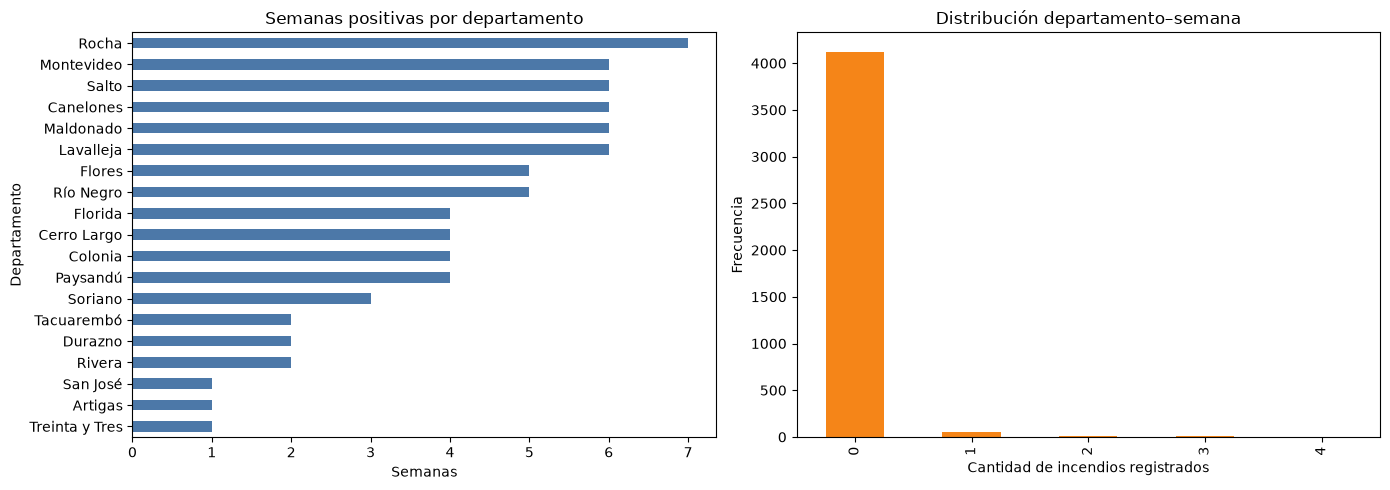

In [11]:
por_departamento = panel.groupby("departamento").agg(
    registros=("cantidad_incendios", "sum"),
    departamento_semanas_positivas=("presencia_incendio", "sum"),
    porcentaje_positivo=("presencia_incendio", lambda s: s.mean() * 100),
).sort_values("registros", ascending=False)
por_anio_panel = panel.assign(anio=panel["fecha_inicio_semana"].dt.year).groupby("anio").agg(
    registros=("cantidad_incendios", "sum"),
    departamento_semanas_positivas=("presencia_incendio", "sum"),
    porcentaje_positivo=("presencia_incendio", lambda s: s.mean() * 100),
)
display(por_departamento.round(3))
display(por_anio_panel.round(3))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
por_departamento["departamento_semanas_positivas"].sort_values().plot.barh(ax=axes[0], color="#4c78a8")
axes[0].set(title="Semanas positivas por departamento", xlabel="Semanas", ylabel="Departamento")
panel["cantidad_incendios"].value_counts().sort_index().plot.bar(ax=axes[1], color="#f58518")
axes[1].set(title="Distribución departamento–semana", xlabel="Cantidad de incendios registrados", ylabel="Frecuencia")
plt.tight_layout()
plt.show()

## 7. Compatibilidad con Open-Meteo

In [12]:
meteo = pd.read_parquet(RUTA_METEO)
meteo["fecha_inicio_semana"] = pd.to_datetime(meteo["fecha_inicio_semana"], errors="raise")
variables_meteo = [
    "temperature_2m_max_mean_weekly",
    "relative_humidity_2m_min_mean_weekly",
    "wind_speed_10m_max_mean_weekly",
    "precipitation_sum_weekly",
]
faltan_variables = [columna for columna in variables_meteo if columna not in meteo.columns]
claves_comunes = panel[["departamento", "fecha_inicio_semana"]].merge(
    meteo[["departamento", "fecha_inicio_semana"]],
    on=["departamento", "fecha_inicio_semana"], how="inner", validate="one_to_one")
print("Período Open-Meteo:", meteo["fecha_inicio_semana"].min().date(), "a", meteo["fecha_inicio_semana"].max().date())
print("Período común potencial:", max(panel["fecha_inicio_semana"].min(), meteo["fecha_inicio_semana"].min()).date(), "a", min(panel["fecha_inicio_semana"].max(), meteo["fecha_inicio_semana"].max()).date())
print("Departamento-semanas potencialmente compartidas:", len(claves_comunes), "de", len(panel))
print("Variables meteorológicas faltantes:", faltan_variables or "ninguna")

Período Open-Meteo: 2017-01-02 a 2025-12-22
Período común potencial: 2018-04-02 a 2022-06-20
Departamento-semanas potencialmente compartidas: 4199 de 4199
Variables meteorológicas faltantes: ninguna


## 8. FIRMS y MIRA: diferencia metodológica

- **FIRMS:** observaciones satelitales de focos de calor o anomalías térmicas; no equivalen automáticamente a incendios confirmados.
- **MIRA en este CSV:** registros etiquetados por tipo de incendio y asociados a las fuentes `sgsp`, `cecoed` o `prensa`. El archivo no contiene un campo de estado o validación que permita sostener que todos fueron confirmados por Bomberos.

Usar MIRA como target cambiaría el fenómeno de interés: de presencia de detecciones satelitales a presencia de eventos registrados en esta base. También incorporaría el proceso de reporte y recopilación de sus fuentes. Antes de reemplazar el target es necesario demostrar cobertura temporal sistemática y establecer una regla espacial para las discrepancias detectadas.

## 9. Conclusiones sobre la viabilidad de MIRA para el PAA

1. El CSV contiene **113 registros** y ninguno es duplicado exacto ni repite sus tres identificadores principales.
2. Las fechas del evento van de **08/04/2018 a 26/06/2022**. Hay registros en cinco años, pero solo dos registros en total durante 2018–2019.
3. La información temporal se puede convertir sin errores, pero la cobertura no es suficiente para asumir observación continua: solo **24 de las 221 semanas** del intervalo tienen algún registro nacional.
4. Los 113 registros declaran uno de los 19 departamentos. La comprobación geoespacial encuentra **tres discrepancias** y **un punto no asignado** mediante `within`; esto exige una decisión de calidad antes de modelar.
5. La grilla exploratoria de 19 × 221 produce **4.199 departamento-semanas**, de las cuales **75** son positivas.
6. El target exploratorio tiene **1,786 % de positivos** y 98,214 % de ceros. Ese cálculo trata semanas intermedias como ceros y, por la cobertura no demostrada, probablemente confunde ausencia de registro con ausencia de incendio.
7. Los 113 eventos y 75 celdas positivas permiten estudiar descriptivamente el fenómeno, pero no ofrecen evidencia suficiente en este archivo para sostener un clasificador temporal representativo del período completo.
8. Las claves son compatibles con Open-Meteo y las cuatro variables actuales están disponibles para las 4.199 combinaciones potenciales. La compatibilidad técnica no resuelve la cobertura del target.
9. Las principales limitaciones son la fuerte concentración en 2021–2022, las 197 semanas nacionales sin registros, 82 valores faltantes en `Área`, la mezcla de fuentes, la falta de un estado de validación y las inconsistencias espaciales.
10. Es razonable continuar estudiando MIRA como fuente complementaria o target alternativo, pero **no es metodológicamente justificable reemplazar todavía `presencia_firms`** usando únicamente este CSV. Se necesita documentación de cobertura, alcance y validación de MIRA, además de una regla espacial auditada.